---
---
# Tensorflow 2 - sieci jednokierunkowe
---
---

# Bibliografia

\begin{enumerate}
\item \textit{S. Raschka, V. Mirjalili}, Python Machine learning i deep learning. Biblioteki scikit-learn i TensorFlow 2,
Wydanie III, Helion, 2021.
\item \textit{A. Geron}, Uczenie maszynowe z uzyciem Scikit-Learn i TensorFlow. Helion, 2018.
\end{enumerate}

## Źródło kodów :

Wszystkie istotne kody umieszczone poniżej pochodzą z  plików Jupyter związanych z pozycją [1] bobliografii. Są one dostępne m.in. w repozytorium [https://github.com/rasbt/python-machine-learning-book-3rd-edition](https://github.com/rasbt/python-machine-learning-book-3rd-edition)

##### Spis treści:

[1. Prosty, testowy przykład sprawdzający działanie tensorflow/keras](#1.-Prosty,-testowy-przykład-sprawdzający-działanie-tensorflow/keras)

[2. Moduł tf.data jako interfejs danych w TensorFlow](#2.-Moduł-tf.data-jako-interfejs-danych-w-TensorFlow)

[3. Model Sequential](#3.-Model-Sequential)

[4. Obliczanie gradientów za pomocą różniczkowania automatycznego i klasy GradientTape](#4.-Obliczanie-gradientów-za-pomocą-różniczkowania-automatycznego-i-klasy-GradientTape)

[5. Tworzenie modelu przez dziedziczenie klasy Model](#5.-Tworzenie-modelu-przez-dziedziczenie-klasy-Model)

[6. Model Functional](#6.-Model-Functional)

[7. Tworzenie niestandardowych warstw Keras](#7.-Tworzenie-niestandardowych-warstw-Keras)

In [22]:
!pip3 install ann_visualizer
!pip install graphviz
!pip install wand
!pip install MagickWand
import numpy as np
from IPython.display import Image
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd
import sys
from IPython.display import display, Math, Latex
import sympy as sym
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from ann_visualizer.visualize import ann_viz;

# 1. Prosty, testowy przykład sprawdzający działanie tensorflow/keras

In [23]:
import tensorflow as tf
mnist = tf.keras.datasets.mnist

(x_train, y_train),(x_test, y_test) = mnist.load_data()#wczytanie danych mnist w keras
x_train, x_test = x_train / 255.0, x_test / 255.0

#print(x_train.shape)#wymiary danych treningowych
#print(x_train[0][15])#16-ty wiersz pierwszego obrazu


model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.2),
  tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=5)
model.evaluate(x_test, y_test)

C:\Users\maria\PycharmProjects\DeepLerning\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9129 - loss: 0.2985
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9571 - loss: 0.1456
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9677 - loss: 0.1081
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9723 - loss: 0.0890
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9762 - loss: 0.0755
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9789 - loss: 0.0711  


[0.07106569409370422, 0.9789000153541565]

# 2. Moduł tf.data jako interfejs danych w TensorFlow

## 2.1. Typ Dataset 

Obiekt tensor, listą Pythona oraz tablicę NumPy, można przekształcić za pomocą  funkcji <i>tf.data.Dataset.from_tensor_slices()</i> do obiektu typu [Dataset](https://www.tensorflow.org/api_docs/python/tf/data/Dataset).

Funkcja ta zwraca obiekt klasy <i>Dataset</i>, dzięki któremu iterujemy po poszczególnych elementach
wejściowego zestawu danych.


In [24]:
a = [1.2, 3.4, 7.5, 4.1, 5.0, 1.0]

ds = tf.data.Dataset.from_tensor_slices(a)

print(ds)

for item in ds:
    print(item)
    

<_TensorSliceDataset element_spec=TensorSpec(shape=(), dtype=tf.float32, name=None)>
tf.Tensor(1.2, shape=(), dtype=float32)
tf.Tensor(3.4, shape=(), dtype=float32)
tf.Tensor(7.5, shape=(), dtype=float32)
tf.Tensor(4.1, shape=(), dtype=float32)
tf.Tensor(5.0, shape=(), dtype=float32)
tf.Tensor(1.0, shape=(), dtype=float32)


#### Obiekty Dataset umożliwiają wiele użytecznych operacji

In [25]:
#utworzenie  grup o rozmiarze 3 z tego zestawu danych - z 6-ciu danych powstaną 2 grupy 

ds_batch = ds.batch(3)

for i, elem in enumerate(ds_batch, 1):
    print('batch {}:'.format(i), elem.numpy())

batch 1: [1.2 3.4 7.5]
batch 2: [4.1 5.  1. ]


In [26]:
#łączenie danych różnego typu typu w jedną krotkę typu Data set

tf.random.set_seed(1)

t_x = tf.random.uniform([4, 3], dtype=tf.float32)#tensor 2-go rzędu wymiaru 4x3
t_y = tf.range(4) #tensor 1-go rzędu wymiary 4x1
print(t_x,"\n")
print(t_y,"\n")

#Musi istnieć zgodność  w stosunku jeden do jednego pomiędzy odpowiednimi elementami obydwu tensorów - w tym przypadku 
#'zewnętrzne' ich wymiary wynoszą 4
    
#utworzenie obiektów Dataset z tensorów    
ds_x = tf.data.Dataset.from_tensor_slices(t_x)
ds_y = tf.data.Dataset.from_tensor_slices(t_y)
    
ds_joint = tf.data.Dataset.zip((ds_x, ds_y))#łączenie obiektów Dataset - utworzenie obiektu 4-elementowego 

print('Po połączeniu\n')
for example in ds_joint:
    print('  x: ', example[0].numpy(), 
          '  y: ', example[1].numpy())



tf.Tensor(
[[0.16513085 0.9014813  0.6309742 ]
 [0.4345461  0.29193902 0.64250207]
 [0.9757855  0.43509948 0.6601019 ]
 [0.60489583 0.6366315  0.6144488 ]], shape=(4, 3), dtype=float32) 

tf.Tensor([0 1 2 3], shape=(4,), dtype=int32) 

Po połączeniu

  x:  [0.16513085 0.9014813  0.6309742 ]   y:  0
  x:  [0.4345461  0.29193902 0.64250207]   y:  1
  x:  [0.9757855  0.43509948 0.6601019 ]   y:  2
  x:  [0.60489583 0.6366315  0.6144488 ]   y:  3


In [27]:
#łączenie tensorów można równoważnie i skrótowo przeprowadzić za pomocą metody tf.data.Dataset.from_tensor_slices():

ds_joint = tf.data.Dataset.from_tensor_slices((t_x, t_y))

print('Po połączeniu\n')
for example in ds_joint:
    print('  x: ', example[0].numpy(), 
          '  y: ', example[1].numpy())

Po połączeniu

  x:  [0.16513085 0.9014813  0.6309742 ]   y:  0
  x:  [0.4345461  0.29193902 0.64250207]   y:  1
  x:  [0.9757855  0.43509948 0.6601019 ]   y:  2
  x:  [0.60489583 0.6366315  0.6144488 ]   y:  3


In [28]:
#skalowanie cech - dane ds_joint przeskalowane do zakresu [−1, 1]

ds_trans = ds_joint.map(lambda x, y: (x*2-1.0, y))

print('Po przeskalowaniu \n')
for example in ds_trans:
    print('  x: ', example[0].numpy(), 
          '  y: ', example[1].numpy())

Po przeskalowaniu 

  x:  [-0.6697383   0.80296254  0.26194835]   y:  0
  x:  [-0.13090777 -0.41612196  0.28500414]   y:  1
  x:  [ 0.951571   -0.12980103  0.32020378]   y:  2
  x:  [0.20979166 0.27326298 0.22889757]   y:  3


In [29]:
#losowe potasowanie składowych obiektu Dataset

tf.random.set_seed(1)
ds = ds_joint.shuffle(buffer_size=len(t_x))

print('Po przetasowniu \n')
for example in ds:
    print('  x: ', example[0].numpy(), 
          '  y: ', example[1].numpy())

Po przetasowniu 

  x:  [0.9757855  0.43509948 0.6601019 ]   y:  2
  x:  [0.4345461  0.29193902 0.64250207]   y:  1
  x:  [0.16513085 0.9014813  0.6309742 ]   y:  0
  x:  [0.60489583 0.6366315  0.6144488 ]   y:  3


<b>Uwaga o funkcji tasującej shuffle():</b>Metoda shuffle() wymaga argumentu o nazwie buffer_size, dzięki któremu określamy liczbę elementów zestawów danych pogrupowanych razem przed rozpoczęciem tasowania. Elementy bufora
są losowo dobierane, a ich miejsce w buforze jest wyznaczane zgodnie z kolejnymi elementami
w pierwotnym (nieprzetasowanym) zestawie danych. Z tego powodu, jeżeli wybierzemy
małą wartość argumentu buffer_size, zestaw danych może zostać niedokładnie potasowany.
Jeżeli zestaw danych jest mały, wybór względnie małego rozmiaru bufora może wpłynąć negatywnie
na wydajność predykcyjną sieci neuronowej, gdyż zestaw danych może nie zostać
całkiem losowo przetasowany. W praktyce jednak jest to właściwie nieodczuwalne podczas
pracy ze względnie dużymi zestawami danych, z którymi mamy dość często do czynienia
w modelach uczenia głębokiego. Ewentualnie, aby zapewnić pełną losowość w każdej epoce,
wystarczy wybrać rozmiar bufora równy liczbie przykładów uczących, tak jak dokonaliśmy
tego w powyższym listingu (buffer_size=len(t_x)).

In [30]:
ds = ds_joint.batch(3)

for example in ds:
    print('  x: ', example[0].numpy(), 
          '  y: ', example[1].numpy(),'\n')
    
it = iter(ds)

batch_x, batch_y = next(it)#pierwsza grupa 

print('Batch-x: \n', batch_x.numpy())

print('Batch-y:   ', batch_y.numpy(),'\n')

batch_x, batch_y = next(it)#druga niepełna grupa

print('Batch-x: \n', batch_x.numpy())

print('Batch-y:   ', batch_y.numpy())


  x:  [[0.16513085 0.9014813  0.6309742 ]
 [0.4345461  0.29193902 0.64250207]
 [0.9757855  0.43509948 0.6601019 ]]   y:  [0 1 2] 

  x:  [[0.60489583 0.6366315  0.6144488 ]]   y:  [3] 

Batch-x: 
 [[0.16513085 0.9014813  0.6309742 ]
 [0.4345461  0.29193902 0.64250207]
 [0.9757855  0.43509948 0.6601019 ]]
Batch-y:    [0 1 2] 

Batch-x: 
 [[0.60489583 0.6366315  0.6144488 ]]
Batch-y:    [3]


In [31]:
#operacja repeat()

ds = ds_joint.repeat(count=2)

for example in ds:
    print('  x: ', example[0].numpy(), 
          '  y: ', example[1].numpy(),'\n')

  x:  [0.16513085 0.9014813  0.6309742 ]   y:  0 

  x:  [0.4345461  0.29193902 0.64250207]   y:  1 

  x:  [0.9757855  0.43509948 0.6601019 ]   y:  2 

  x:  [0.60489583 0.6366315  0.6144488 ]   y:  3 

  x:  [0.16513085 0.9014813  0.6309742 ]   y:  0 

  x:  [0.4345461  0.29193902 0.64250207]   y:  1 

  x:  [0.9757855  0.43509948 0.6601019 ]   y:  2 

  x:  [0.60489583 0.6366315  0.6144488 ]   y:  3 



In [32]:
#łączenie operacji: batch() -> repeat()

ds = ds_joint.batch(3).repeat(count=2)

for example in ds:
    print('  x: ', example[0].numpy(), 
          '  y: ', example[1].numpy(),'\n')

  x:  [[0.16513085 0.9014813  0.6309742 ]
 [0.4345461  0.29193902 0.64250207]
 [0.9757855  0.43509948 0.6601019 ]]   y:  [0 1 2] 

  x:  [[0.60489583 0.6366315  0.6144488 ]]   y:  [3] 

  x:  [[0.16513085 0.9014813  0.6309742 ]
 [0.4345461  0.29193902 0.64250207]
 [0.9757855  0.43509948 0.6601019 ]]   y:  [0 1 2] 

  x:  [[0.60489583 0.6366315  0.6144488 ]]   y:  [3] 



In [33]:
#łączenie operacji: shuffle() -> batch() -> repeat() - pewien wzorzec dla procesu uczenia

ds = ds_joint.shuffle(4).batch(2).repeat(3)


for example in ds:
    print('  x: ', example[0].numpy(), 
          '  y: ', example[1].numpy(),'\n')

  x:  [[0.4345461  0.29193902 0.64250207]
 [0.9757855  0.43509948 0.6601019 ]]   y:  [1 2] 

  x:  [[0.60489583 0.6366315  0.6144488 ]
 [0.16513085 0.9014813  0.6309742 ]]   y:  [3 0] 

  x:  [[0.4345461  0.29193902 0.64250207]
 [0.60489583 0.6366315  0.6144488 ]]   y:  [1 3] 

  x:  [[0.16513085 0.9014813  0.6309742 ]
 [0.9757855  0.43509948 0.6601019 ]]   y:  [0 2] 

  x:  [[0.9757855  0.43509948 0.6601019 ]
 [0.4345461  0.29193902 0.64250207]]   y:  [2 1] 

  x:  [[0.60489583 0.6366315  0.6144488 ]
 [0.16513085 0.9014813  0.6309742 ]]   y:  [3 0] 



## 2.2. Tworzenie zestawu danych z plików umieszczonych w lokalnym magazynie dyskowym

Stworzymy zestaw danych z plików obrazów przechowywanych na dysku. Posłużymy się lokalnym katalogiem ze zdjęciami psów i kotów w formacie JPEG (trzy zdjęcia psów i trzy zdjęcia kotów).

Na tym zestawie danych zaprezentujemy ogólny mechanizm tworzenia zestawu danych z przechowywanych plików. Wykorztsamy w tym celu dwa dodatkowe moduły TensorFlow:

- tf.io - do odczytywania plików 
- tf.image do rozkodowania nieprzetworzonej zawartości oraz do zmiany rozmiarów obrazów

<b>Uwaga</b>: Moduły tf.io oraz tf.image zawierają wele dodatkowych i przydatnych funkcji, których opis
można znaleźć w oficjalnej dokumentacji:
- [moduł tf.io](https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/io)
- [moduł tf.image]( https://www.tensorflow.org/versions/r2.0/api_docs/python/tf/image)



['cat_dog_images\\cat-01.jpg', 'cat_dog_images\\cat-02.jpg', 'cat_dog_images\\cat-03.jpg', 'cat_dog_images\\dog-01.jpg', 'cat_dog_images\\dog-02.jpg', 'cat_dog_images\\dog-03.jpg']
Image shape:  (900, 1200, 3)
Image shape:  (900, 1200, 3)
Image shape:  (900, 742, 3)
Image shape:  (800, 1200, 3)
Image shape:  (800, 1200, 3)
Image shape:  (900, 1200, 3)


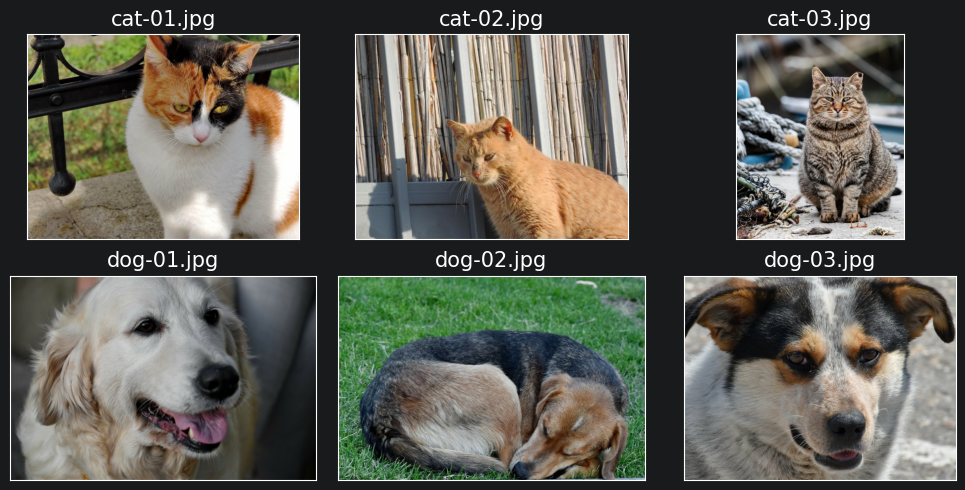

In [34]:
#odczyt zawartości katalogu  z plikami - biblioteka pathlib oraz ich wizualizacja

import pathlib

imgdir_path = pathlib.Path('cat_dog_images')

file_list = sorted([str(path) for path in imgdir_path.glob('*.jpg')])

print(file_list)# lista plików - prefiksy nazw (dog, cat) mogą zostać wykorzystne do generowania etykiet klasyfikacyjnych

#wizualizacja
import os



fig = plt.figure(figsize=(10, 5))
for i,file in enumerate(file_list):
    img_raw = tf.io.read_file(file)#funkcja tf.io.read_file zwraca tensor, czyli zawiera m.in. składowe: shape oraz numpy
    #print(img_raw)
    img = tf.image.decode_image(img_raw)#dekoduje piksele na tablice 3 składowych rgb w języku [0,255]
    print('Image shape: ', img.shape)
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(img)# dokumentacja: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html
    ax.set_title(os.path.basename(file), size=15)
    
plt.tight_layout()
plt.show()


In [35]:
#wygenerowanie tablicy etykiet dla plików

labels = [1 if 'dog' in os.path.basename(file) else 0 for file in file_list]
print(labels)

[0, 0, 0, 1, 1, 1]


In [36]:
# łączenie nazw plików  i etykiet w obiekt Dataset

ds_files_labels = tf.data.Dataset.from_tensor_slices((file_list, labels))

for item in ds_files_labels:
    print(item[0].numpy(), item[1].numpy())

b'cat_dog_images\\cat-01.jpg' 0
b'cat_dog_images\\cat-02.jpg' 0
b'cat_dog_images\\cat-03.jpg' 0
b'cat_dog_images\\dog-01.jpg' 1
b'cat_dog_images\\dog-02.jpg' 1
b'cat_dog_images\\dog-03.jpg' 1


In [37]:
# funkcja pomocnicza wczytująca zawartość obrazu ze ścieżki pliku, rozkodowująca nieprzetworzoną treść 
# i zmieniająca rozmiary do pożądanej proporcji, np. 80×120 oraz normalizująca wartości składowych rgb do [0,1]

def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [img_height, img_width])
    image /= 255.0

    return image, label


In [38]:
# skalowanie i normalizacja danych

img_width, img_height = 120, 80

ds_images_labels = ds_files_labels.map(load_and_preprocess)


(80, 120, 3) 0
(80, 120, 3) 0
(80, 120, 3) 0
(80, 120, 3) 1
(80, 120, 3) 1
(80, 120, 3) 1


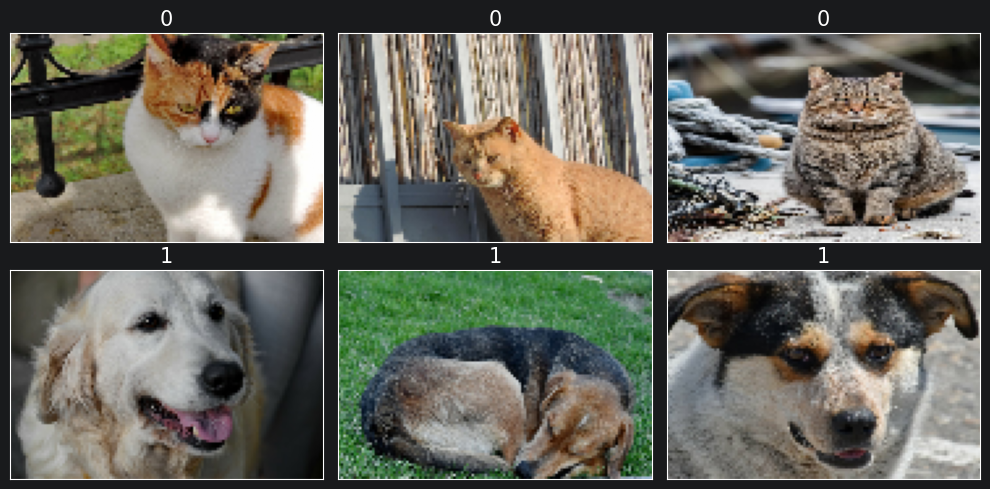

In [39]:
#wizualizacja obrazów po normalizcaji i skalowaniu

fig = plt.figure(figsize=(10, 5))
for i,example in enumerate(ds_images_labels):
    print(example[0].shape, example[1].numpy())
    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(example[0])
    ax.set_title('{}'.format(example[1].numpy()), 
                 size=15)
    
plt.tight_layout()
plt.show()

## 2.3. Pobieranie dostępnych zestawów danych z biblioteki tensorflow_datasets



In [40]:
import tensorflow_datasets as tfds

#funkcja list_builders generuje listę nazw dostępnych zestawów danych
print(len(tfds.list_builders()))
print(tfds.list_builders()[:5])

1314
['abstract_reasoning', 'accentdb', 'aeslc', 'aflw2k3d', 'ag_news_subset']


#### Istnieją dwa sposoby wczytywania zestawów:

\begin{enumerate}
\item Pierwsza technika jest trójetapowa:
\begin{enumerate}
\item Wywołanie konstruktora zestawu danych.
\item Realizacja metody download_and_prepare().
\item Wywołanie metody as_dataset().
\end{enumerate}
\item Druga strategia polega na wykorzystaniu funkcji load(), która za jednym zamachem realizuje wszystkie trzy powyższe etapy
wcześniej etapy pobierania zestawu danych
\end{enumerate}
<p></p>
Zrealizujmy pierwszy etap na przykładzie zestawu CelebA i wyświetlmy dostępny w bibliotece

In [41]:
# Technika 1 na zestawie mnist

# 1.1. wywołanie konstruktora zestawu mnist
mnist_bldr = tfds.builder('mnist')# wywołanie konstruktora zestawu mnist
print(type(mnist_bldr))

# Wyświetlenie różnych informacji o zestawie danych
print(mnist_bldr.info.features)
print('\n', 30*"=", '\n')
print(mnist_bldr.info.features.keys())#Cechy są przechowane jako słownik zawierający trzy klucze: 'image', 'landmarks' i 'attributes'.
print('\n', 30*"=", '\n')
print(mnist_bldr.info.features['image'])
print('\n', 30*"=", '\n')
print(mnist_bldr.info.features['label'])
print('\n', 30*"=", '\n')
print(mnist_bldr.info.citation)

# 1.2. wywołanie metody download_and_prepare() - załadowanie danych na  dysk
#utworzenie katalogu C:\Users\username\tensorflow_datasets\mnist\3.0.1.
mnist_bldr.download_and_prepare()

# 1.3. Wywołanie metody as_dataset() -  załadowanie  danych z dysku  jako tf.data.Datasets
datasets = mnist_bldr.as_dataset(shuffle_files=False)
datasets.keys()


RuntimeError: AttributeError: Failed to construct dataset "mnist", builder_kwargs "{}": 'google._upb._message.FieldDescriptor' object has no attribute 'label'

In [ ]:
#zdefiniowanie obiektu Dataset z danych treningowych
ds_train = datasets['train']
assert isinstance(ds_train, tf.data.Dataset)

example = next(iter(ds_train))
print(type(example))
print(example.keys())

In [ ]:
ds_train = ds_train.map(lambda item: 
     (item['image'], item['label']))

ds_train = ds_train.batch(10)
batch = next(iter(ds_train))
print(batch[0].shape, batch[1])

fig = plt.figure(figsize=(15, 6))
for i,(image,label) in enumerate(zip(batch[0], batch[1])):
    ax = fig.add_subplot(2, 5, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(image[:, :, 0], cmap='gray_r')
    ax.set_title('{}'.format(label), size=15)
    
plt.show()
# informacje w przypadku  ewentualnego ostrzeżenia: https://github.com/tensorflow/tensorflow/issues/37144

In [ ]:
#  Technika 2 na zestawie mnist

mnist, mnist_info = tfds.load('mnist', with_info=True,
                              shuffle_files=False)

print(mnist_info)

print(mnist.keys())

In [ ]:
ds_train = mnist['train']

assert isinstance(ds_train, tf.data.Dataset)

ds_train = ds_train.map(lambda item: 
     (item['image'], item['label']))

ds_train = ds_train.batch(10)
batch = next(iter(ds_train))
print(batch[0].shape, batch[1])

fig = plt.figure(figsize=(15, 6))
for i,(image,label) in enumerate(zip(batch[0], batch[1])):
    ax = fig.add_subplot(2, 5, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(image[:, :, 0], cmap='gray_r')
    ax.set_title('{}'.format(label), size=15)
    
plt.show()

# 3. Model Sequential

Istotne informacje: https://www.tensorflow.org/guide/keras/sequential_model

##### Referencje:

InputLayer:http://man.hubwiz.com/docset/TensorFlow.docset/Contents/Resources/Documents/api_docs/python/tf/keras/layers/InputLayer.html

Dense: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense

## 3.1. Ogólna koncepcja

### 3.1.1. Dodanie warstw 

Możemy to zrobić na dwa sposoby:
    
- przekazanie listy warstw do konstruktora 
- używając funkcji <tt>add</tt>

In [ ]:
# Sposób 1: Przekazanie listy warstw do konstruktora
model1 = keras.Sequential(
    [
        layers.InputLayer(input_shape=(4,)),#tensor wejściowy ma format 4-elementowego wektora
        layers.Dense(2, activation="relu"),#warstwa gęsta składająca się z 2 neuronów, z funkcją aktywacji ReLu
        layers.Dense(3, activation="relu"),#warstwa gęsta składająca się z 3 neuronów, z funkcją aktywacji ReLu
        layers.Dense(4),#warstwa gęsta składająca się z dwóch neuronów, z funkcją aktywacji Id (tak jest pomimo, że domyślnie activation=None )
    ]
)

# Sposób 2: Przekazanie listy warstw do konstruktora
model2 = keras.models.Sequential()
model2.add(layers.InputLayer(input_shape=(4,))),#tensor wejściowy ma format 4-elementowego wektora
model2.add(layers.Dense(2, activation="relu")),#warstwa gęsta składająca się z 2 neuronów, z funkcją aktywacji ReLu
model2.add(layers.Dense(3, activation="relu")),#warstwa gęsta składająca się z 3 neuronów, z funkcją aktywacji ReLu
model2.add(layers.Dense(4)),#warstwa gęsta składająca się z dwóch neuronów, z funkcją aktywacji Id (tak jest pomimo, że domyślnie activation=None )
 

In [ ]:
print(model1)
print(layers.InputLayer(input_shape=(4,)))
print(layers.Dense(2, activation="relu"))


In [ ]:
#Param wskazuje na ilość wag   dla warstw gęstych (warstwa gęsta 0 ma 4 wagi wejściowe i dodaje w każdym swoim neuronie 
#po jednej wadze bias - w efekcie każdy z dwóch neuronów warstwy gęstej 0 działa na 5 danych)
model1.summary()

In [ ]:
model2.summary()

In [ ]:
print(model1.layers[0].input_shape)
print(model1.layers[0].output_shape)

In [ ]:
print(model1.layers[0])
print(type(model1.layers[0].trainable_weights[0]))#wagi (w tym przypadku 'niezamrożone' warstw 0-1) są typu modyfikowalnego
print(model1.layers[0].trainable_weights[0])

In [ ]:
#prosty sposób odczytu wszystkich wag i obciążeń
all_weights = model1.layers[0].get_weights()#10 wag z warstwy 0
weights = all_weights[0]
biases = all_weights[1]
print(all_weights)
print(weights)
print(biases)

In [ ]:
#Przypadek sieci z warstwą Flatten

model3 = keras.models.Sequential()

model3.add(keras.layers.Flatten(input_shape=[28, 28]))#warstwa Flatten (czyli warstwa 0) nie ma oczywiście wag wejściowych - nic nie liczy, tylko spłaszcza
model3.add(keras.layers.Dense(256, activation="relu"))
model3.add(keras.layers.Dense(128, activation="relu"))
model3.add(keras.layers.Dense(10, activation="softmax"))
print(model3.layers[0])
print(model3.layers[0].input_shape)
print(model3.layers[0].output_shape)
print(model3.layers[0].get_weights())# pusty wektor wag warstwy Flatten 

In [ ]:
#wybrane informacje z warstwy
info={'name':model1.layers[0].name, 'trainable_weights':model1.layers[0].trainable_weights}
print(info)


### 3.1.2. Wizualizacja struktury sieci

In [ ]:
# Wizualizacja sieci: https://github.com/RedaOps/ann-visualizer (ann-visualizer używa graphviz: https://graphviz.org/)
#ann_viz(model1, title="Wizualizacja sieci gęstej", view=True, filename="dense_network.gv")

In [ ]:
#wyświetlenie pdf w Jupyter notebook: moduły wand, Magickwand - trzeba również zainstalować ImageMagic w systemie operacyjnym

from wand.image import Image as WImage
img = WImage(filename='dense_network.gv.pdf')
img

In [ ]:
#inny sposób wizualizacji - funkcja plot_model z biblioteki keras

from tensorflow.keras.utils import plot_model 

plot_model(model1, to_file='model1_plot.png', show_shapes=True,show_dtype=True, show_layer_names=True, expand_nested=True,)


In [ ]:
#model2 jest identyczny jak model1

plot_model(model2, to_file='model2_plot.png', show_shapes=True,show_dtype=True, show_layer_names=True, expand_nested=True,)

In [ ]:
plot_model(model3, to_file='model3_plot.png', show_shapes=True,show_dtype=True, show_layer_names=True, expand_nested=True,)

## 3.2.  Dobór funkcji aktywacji dla wielowarstwowych sieci neuronowych


### 3.2.1.  Funkcja logistyczna

Logistyczna funkcja aktywacji prawdopodobnie w największym
stopniu odwzorowuje działanie rzeczywistej komórki nerwowej: możemy ją sobie wyobrazić
jako prawdopodobieństwo pobudzenia neuronu. Logistyczna (sigmoidalna) funkcja aktywacji
staje się jednak nieprzydatna w przypadku ujemnych danych wejściowych, ponieważ
wówczas jej wartość byłaby zbliżona do zera. Jeśli wartość funkcji sigmoidalnej zbliża się do
zera, sieć neuronowa uczy się bardzo powoli i zwiększa się ryzyko utknięcia algorytmu
w lokalnym minimum funkcji kosztu na etapie trenowania. Dlatego analitycy często wybierają
funkcję tangensa hiperbolicznego jako funkcję pobudzenia w warstwach ukrytych (zob. 3.2.3).

Jak było to już pokazane funkcji logistycznej możemy używać do modelowania prawdopodobieństwa
przynależności próby x do klasy pozytywnej (klasy 1) w klasyfikacji binarnej.

#### Przykład: 
Załóżmy, że mamy do czynienia z modelem analizującym dwuwymiarowy
punkt danych x  oraz zawierającym poniższe współczynniki wag przydzielone do
wektora w (w0 jest jednostką obciążenia (punkt przecięcia z osią y, co oznacza, że x0 = 1):


In [ ]:
import numpy as np

X = np.array([1, 1.4, 2.5]) ## pierwsza wartość musi być równa 1
w = np.array([0.4, 0.3, 0.5])

def net_input(X, w):
    return np.dot(X, w)

def logistic(z):
    return 1.0 / (1.0 + np.exp(-z))

def logistic_activation(X, w):
    z = net_input(X, w)
    return logistic(z)

print('P(y=1|x) = %.3f' % logistic_activation(X, w)) 

Otrzymamy wynik 0,888 interpretujemy jako 88,8% prawdopodobieństwa na przynależność próby x do klasy
pozytywnej.

<b>Uwaga</b> warstwa wyjściowa
zawierająca wiele jednostek aktywacji logistycznej generuje w ogólnosci absurdalne, nieinterpretowalne
wartości prawdopodobieństwa. W poniższym przykładzie na wejściu  warstwy (czyli w ogólności wyjściu poprzedniej warstwy ukrytej) podawane są  trzy wartości 0.1, 0.4, 0.6. Zakładamy, że należą one do trzech różnych klas, stąd na wyjściu generujemy 3 liczby. Jak widać, nie możemy interpretować otrzymanych wartości jako prawdopodobieństwa
przynależności do klasy w problemie trójklasowym. Wynika to z tego, że ich suma nie jest
równa 1. 


In [ ]:
# W : tablica, wymiary = [n_jednostek_wyjściowych, n_jednostek_ukrytych+1]
#   zwróć uwagę, że pierwsza kolumna zawiera jednostki obciążenia

W = np.array([[1.1, 1.2, 0.8, 0.4],
              [0.2, 0.4, 1.0, 0.2],
              [0.6, 1.5, 1.2, 0.7]])

# A : tablica, wymiary = [n_jednostek_ukrytych+1, n_przykładów]
#    zwróć uwagę, że pierwsza kolumna w tej tablicy musi być równa 1


A = np.array([[1, 0.1, 0.4, 0.6]])
Z = np.dot(W, A[0])
y_probas = logistic(Z)
print('Pobudzenie całkowite: \n', Z)

print('Jednostki wyjściowe:\n', y_probas) 

W rzeczywistości nie jest to duży problem, jeżeli używamy modelu jedynie do przewidywania
etykiet klas, a nie prawdopodobieństw przynależności do poszczególnych klas. Jednym
ze sposobów przewidywania etykiet klas z uzyskanych wcześniej jednostek wyjściowych
jest wykorzystanie wartości maksymalnej:

In [ ]:
y_class = np.argmax(Z, axis=0)
print('Przewidywana etykieta klas: %d' % y_class) 

Jednak W pewnych sytuacjach przydaje się możliwość obliczenia sensownych wartości prawdopodobieństwa
przynależności do klas podczas predykcji wieloklasowych. W dalszej części rozdziału
przyjrzymy się uogólnieniu funkcji logistycznej, tzw. funkcji softmax, która świetnie
nadaje się do wspomnianego zadania.

### 3.2.2.  Funkcja softmax  - szacowanie prawdopodobieństw przynależności do klas w klasyfikacji wieloklasowej

Funkcja softmax stanowi w istocie „miękką” odmianę funkcji argmax; dzięki niej otrzymujemy
nie pojedynczy indeks klasy, lecz prawdopodobieństwo przynależności do każdej z nich.
Zatem funkcja softmax umożliwia nam wyliczanie sensownych prawdopodobieństw przynależności
do klas w konfiguracjach wieloklasowych (wielomianowa regresja logistyczna).
Funkcja softmax zwraca wektor prawdopodobieństw przynależności danej próby o całkowitym pobudzeniu
$z=(z_i)_1^M$ do zbioru M klas. Prawdopodobieństwo  przynależności do i-tej klasy jest wyliczane za pomocą wyrażenia normalizującego występującego w mianowniku
— tj. sumy funkcji liniowych ważonych wykładniczo:
$$
p(z)_i =\varphi(z)_i = \frac{e^{z_i}}{\sum_{j=1}^Me^{z_i}}
$$

In [ ]:
def softmax(z):
    return np.exp(z) / np.sum(np.exp(z))

y_probas = softmax(Z)#Z jest z przykładu powyżej
print('Prawdopodobieństwa:\n', y_probas)

np.sum(y_probas)

Jak widać, prawdopodobieństwa przynależności do klas sumują się teraz do wartości 1, co jest
zgodne z oczekiwaniami. Warto również zwrócić uwagę, że przewidywana etykieta klas jest
taka sama jak w przypadku użytej w regresji logistycznej funkcji argmax.


Możemy myśleć o funkcji softmax jako o znormalizowanym wyniku, przydatnym do uzyskiwania
wiarygodnych prognoz przynależności określonych instancji do wyznaczonych grup w środowiskach
wieloklasowych. Zatem w trakcie tworzenia modelu klasyfikacji wieloklasowej w Tensorflow możemy za pomocą funkcji tf.keras.activations.softmax() oszacować prawdopodobieństwo
przynależności do każdej klasy dla każdej grupy przykładów. Aby wykorzystać funkcję
softmax w TensorFlow, przekształcimy zmienną Z w tensor i zarezerwujemy dodatkowy wymiar
na rozmiar grupy ([dokumentacja funkcji tf.expand_dims](https://www.tensorflow.org/api_docs/python/tf/expand_dims)):

In [ ]:
import tensorflow as tf

Z_tensor = tf.expand_dims(Z, axis=0)
tf.keras.activations.softmax(Z_tensor)

### 3.2.3.  Rozszerzanie zakresu wartości wyjściowych za pomocą funkcji tangensa hiperbolicznego
Funkcja tangensa hiperbolicznego jak wiadomo definiowana jest przez formułę:
$$
\tanh(z) = \frac{e^z-e^{-z}}{e^z+e^{-z}}
$$
Przewagą funkcji tangensa hiperbolicznego nad funkcja logistyczną jest szerszy zakres wartości
wyjściowych w zakresie przedziału otwartego (–1, 1), co poprawia zbieżność algorytmu wstecznej
propagacji. Poniżej pokazano porównanie wykresów tych funkcji.

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

def tanh(z):
    e_p = np.exp(z)
    e_m = np.exp(-z)
    return (e_p - e_m) / (e_p + e_m)

z = np.arange(-5, 5, 0.005)
log_act = logistic(z)
tanh_act = tanh(z)
plt.ylim([-1.5, 1.5])
plt.xlabel('Pobudzenie całkowite $z$')
plt.ylabel('Aktywacja $\phi(z)$')
plt.axhline(1, color='black', linestyle=':')
plt.axhline(0.5, color='black', linestyle=':')
plt.axhline(0, color='black', linestyle=':')
plt.axhline(-0.5, color='black', linestyle=':')
plt.axhline(-1, color='black', linestyle=':')
plt.plot(z, tanh_act,
    linewidth=3, linestyle='--',
    label='Funkcja tanh')
plt.plot(z, log_act,
    linewidth=3,
    label='Funkcja logistyczna')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


Funkcja tanh() jest wbudowana zarówno w numPy jak i Tensorflow:

In [ ]:
np.tanh(z)

In [ ]:
import tensorflow as tf

tf.keras.activations.tanh(z)

Ponadto funkcja logistyczna jest również dostępna w Tensorflow, a także w SciPy:

In [ ]:
from scipy.special import expit

expit(z)

In [ ]:
tf.keras.activations.sigmoid(z)

### 3.2.4. Aktywacja za pomocą prostowanej jednostki liniowej (ReLU)

Prostowana jednostka liniowa (ang. Rectified Linear Unit — ReLU) to kolejna funkcja aktywacji
często wykorzystywana w głębokich sieciach neuronowych. Zanim spróbujemy ją
zrozumieć, powinniśmy najpierw poznać problem zanikającego gradientu w funkcjach aktywacji
tanh i logistycznej.

W celu wyjaśnienia tego problemu załóżmy, że początkowo mamy pobudzenie całkowite
o wartości $z_1 = 20$ które następnie ulega zmianie do wartości $z_2=25$. Po obliczeniu funkcji
aktywacji tanh uzyskujemy wyniki $\varphi(z_1)=1.0$ i$\varphi(z_2)=1.0$ , co oznacza brak zmian na wyjściu
(z powodu asymptotycznych własności funkcji tanh i błędów numerycznych).

Podobnie niedobrze jest dla funkcji logistycznej. Jeżeli oznaczymy ją przez $S(x)$, to łatwo sprawdzić, że $S'(x)=S(x)(1-S(x))$. Oznacza to, że dla dużych wartości $x$ zachodzi $S'(x)\rightarrow 1(1-1)=0$, czyli gradienty znikają. W istocie funkcja logistyczna ma zwykle małą pochodną (istotnie mniejszą niż 1), więc propagacja wsteczna w sieciach wielowarstwowych daje szybką redukcję gradientu niezależnie od wielkości danych, czyli w zasadzie nie nadaje się do uczenia głębokiego (w warstwach ukrytych). Poniższy rysunek pokazuje wykresy pochodnych trzech funkcji.

![sigmoid_tanh_relu_gradient](images/sigmoid_tanh_relu_gradient.png)

Możemy z tego wywnioskować, że pochodna funkcji aktywacji w stosunku do pobudzenia
całkowitego maleje wraz ze wzrostem wartości z. W konsekwencji wyznaczanie wag w trakcie
uczenia staje się bardzo powolne, ponieważ wartości gradientu mogą być bliskie zera. Rozwiązaniem
tego problemu jest właśnie funkcja ReLU. W ujęciu matematycznym definiujemy ją
następująco:
$$
\varphi(z)=max(0,z)
$$

Jednostka ReLU jest funkcją nieliniową, która nadaje się do trenowania złożonych funkcji za
pomocą sieci neuronowych. Poza tym pochodna wartości ReLU (w odniesieniu do wejścia)
jest zawsze równa 1 dla dodatnich wartości wejściowych. Rozwiązuje to zatem problem zanikającego
gradientu, dzięki czemu funkcja ta przydaje się w głębokich sieciach neuronowych. W module
TensorFlow możemy stosować funkcję ReLU następująco:

In [ ]:
import tensorflow as tf

tf.keras.activations.relu(z)

Wszystkie dostępne w module keras funkcje aktywacji są opisane na stronie [keras/activations](https://www.tensorflow.org/api_docs/python/tf/keras/activations)

## 3.3. Przykład produkcyjny

## Tworzenie perceptronu wielowarstwowego klasyfikującego kwiaty z zestawu danych Iris
=======================================================================================================================

### 3.3.1. Wczytanie danych

In [ ]:
#wczytanie danych z datasets
import tensorflow_datasets as tfds

iris, iris_info = tfds.load('iris', with_info=True)

print(iris_info)

### 3.3.2. Tasowanie danych

Jeżeli zestaw danych nie był potasowany,
możemy teraz to zrobić. Musimy jednak bardzo uważać, ponieważ mogą zostać wymieszane
przykłady uczące z testowymi, co jest niedopuszczalne w uczeniu maszynowym. Aby tego uniknąć,
musimy wyznaczyć argument reshuffle_each_iteration=False w metodzie .shuffle().
Kod podziału zestawu danych na zbiory uczący/testowy wygląda następująco:

In [ ]:
tf.random.set_seed(1)

ds_orig = iris['train']
ds_orig = ds_orig.shuffle(150, reshuffle_each_iteration=False)

print(next(iter(ds_orig)))

ds_train_orig = ds_orig.take(100)
ds_test = ds_orig.skip(100)

In [ ]:
## sprawdza liczbę przykładów:

n = 0
for example in ds_train_orig:
    n += 1
print(n)


n = 0
for example in ds_test:
    n += 1
print(n)

### 3.3.3. Łączenie danych z etykietami

Kolejnym etapem jest wprowadzenie przekształcenia polegającego na uzyskaniu krotki ze słownika za pomocą metody .map():

In [ ]:
ds_train_orig = ds_train_orig.map(
    lambda x: (x['features'], x['label']))

ds_test = ds_test.map(
    lambda x: (x['features'], x['label']))

next(iter(ds_train_orig))

### 3.3.4. Tworzenie warstw sieci

Chcemy tu zdefiniować model zawierający
dwie warstwy ukryte. Pierwsza z nich otrzymuje na wejściu cztery cechy i rzutuje je na 16 neuronów.
Druga warstwa otrzymuje na wejściu wynik poprzedniej warstwy (o rozmiarze 16) i rzutuje
je na trzy neurony wyjściowe, ponieważ dysponujemy tyloma etykietami klas.

W pierwszej warstwie wprowadziliśmy sigmoidalną funkcję aktywacji, natomiast w ostatniej
(wyjściowej) umieściliśmy funkcję softmax. Funkcja softmax w ostatniej warstwie jest stosowana
w zadaniach klasyfikacji wieloklasowej, gdyż mamy w naszym przypadku trzy etykiety klas
(wyjaśnia to, dlaczego ostatnia warstwa zawiera trzy neurony).

In [ ]:
iris_model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='sigmoid', 
                          name='fc1', input_shape=(4,)),
    tf.keras.layers.Dense(3, name='fc2', activation='softmax')])

iris_model.summary()

### 3.3.5. Kompilacja sieci - funkcja compile()

W istocie funkcja ta pełni jedynie rolę definicji trzech obliczeniowych parametrów sieci neuronowej: określa funkcję straty,
algorytm optymalizacji oraz metodę obliczania jakości sieci (metryka):

In [ ]:
iris_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

Parametry te są opisane w dokumentacji:

- [Funkcje straty w Keras](https://keras.io/api/losses/) 

- [Metryki w Keras](https://keras.io/api/metrics/)

- [Optymalizatory w Keras](https://keras.io/api/optimizers/) 

### 3.3.6. Uczenie sieci - funkcja fit()

Funkcja fit w ogólności specyfikuje dużą ilość parametrów (zob. [dokumentacja](https://www.tensorflow.org/api_docs/python/tf/keras/Model#fit)), ale zwykle podajemy tylko kilka: dane treningowe, etykiety, dane walidacyjne, rozmiar batch'a oraz ilość epok. 

Ze względu na sporo niejasności w rozróżnianu danych testowych i walidacyjnych odsyłamy tu do dobrego wyjaśnienia tych pojęć 
[Test_vs_validation](file:///C:/Users/fraktal/Downloads/What%20is%20the%20Difference%20Between%20Test%20and%20Validation%20Datasets_.html)

Pojęcia epoki i rozmiaru batch'a były wyjaśnione przy implementacji MLP w pliku [nn_1.ipynb](nn_1.ipynb). Przypomnijmy tylko, że wagi sieci są uaktualniane raz na 1 batch, a jej wydajność (metryka) jest obliczana po przejściu całej epoki.  

In [ ]:
num_epochs = 100
training_size = 100
batch_size = 2
steps_per_epoch = np.ceil(training_size / batch_size)

ds_train = ds_train_orig.shuffle(buffer_size=training_size)
ds_train = ds_train.repeat()
ds_train = ds_train.batch(batch_size=batch_size)
ds_train = ds_train.prefetch(buffer_size=1000)


history = iris_model.fit(ds_train, epochs=num_epochs,
                         steps_per_epoch=steps_per_epoch, 
                         verbose=0)
print(history)

Zwracana historia zmiennych przechowuje wartości funkcji straty uczenia i dokładności uczenia
(wyznaczyliśmy te wskaźniki w iris_model.compile()) po każdej epoce. Możemy dzięki temu
zwizualizować krzywe uczenia w następujący sposób:

In [ ]:
hist = history.history

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(hist['loss'], lw=3)
ax.set_title('Funkcja straty uczenia', size=15)
ax.set_xlabel('Epoka', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(hist['accuracy'], lw=3)
ax.set_title('Dokładność uczenia', size=15)
ax.set_xlabel('Epoka', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.tight_layout()
#plt.savefig('r13-cls-krzywa-uczenia.pdf')

plt.show()

### 3.3.7. Ocena wytrenowanego modelu za pomocą danych testowych

In [ ]:
results = iris_model.evaluate(ds_test.batch(50), verbose=0)
print('F. straty (test): {:.4f}   Dokładność (test): {:.4f}'.format(*results))

### 3.3.8. Zapisywanie  wyuczonego modelu

Możemy zapisywać wytrenowane modele na dysk do późniejszego użytku. Dokonujemy tego
następująco:

In [ ]:
iris_model.save('iris-klasyfikator.h5', 
                overwrite=True,
                include_optimizer=True,
                save_format='h5')

#iris_model.to_json()

Pierwszą opcją jest nazwa pliku. Wywołanie metody iris_model.save() spowoduje zapisanie
zarówno architektury modelu, jak i wszystkich wyuczonych parametrów. Jeśli jednak chcesz
zapisać tylko architekturę, możesz skorzystać z metody iris_model.to_json(), która zapisuje
konfigurację modelu w formacie JSON. Ewentualnie możesz także zapisać tylko wagi modelu
za pomocą wywołania metody iris_model.save_weights(). Atrybut save_format może przyjmować
wartości 'h5' (format HDF5) lub 'tf' (format TensorFlow).

### 3.3.9. Wczytywanie wyuczonego modelu

Wczytajmy teraz zapisany model. Zapisaliśmy zarówno strukturę modelu, jak i wagi, zatem możemy
z łatwością odtworzyć i wczytać parametry za pomocą jednego wiersza kodu:

In [ ]:
iris_model_new = tf.keras.models.load_model('iris-klasyfikator.h5')

iris_model_new.summary()

Na koniec oceńmy ten wczytany model na zbiorze testowym, aby sprawdzić, czy rezultaty będą
takie same jak poprzednio:

In [ ]:
results = iris_model.evaluate(ds_test.batch(50), verbose=0)
print('F. straty (test): {:.4f}   Dokładność (test): {:.4f}'.format(*results))

### 3.3.10. Wykorzystanie wyuczonego modelu do nowych danych¶

Aby przewidywać wartości zmiennej celu na nowych punktach danych, możemy użyć metody
predict(). Załóżmy na potrzeby omawianego przykładu, że zbiór testowy reprezentuje zestaw
nowych, nieoznakowanych punktów danych.

Zwróć uwagę, że w rzeczywistych zadaniach przewidywania funkcja wejściowa będzie musiała
zwracać jedynie zestaw danych składający się z cech przy założeniu, że etykiety są niedostępne.
W naszym przypadku skorzystamy po prostu z tej samej funkcji wejściowej, co podczas oceniania
modelu; otrzymamy w ten sposób przewidywania dla każdego przykładu:

In [ ]:
pred_res = iris_model.predict(ds_test.batch(50))
y_test
#pred_res
#actual = np.argmax(y_test,axis=1)
#predicted = np.argmax(y_pred,axis=1)

## 3.4. Rozwiązywanie problemu klasyfikacji XOR

Klasyfikacja XOR stanowi klasyczny problem analizowania pojemności modelu w odniesieniu
do określania nieliniowej granicy decyzyjnej pomiędzy dwiema klasami. Wygenerujemy
przykładowy zestaw danych składający się z 200 przykładów uczących losowanych z jednostajnego
rozkładu w przedziale $[−1, 1)$, zawierający dwie cechy $(x_0, x_1)$. Następnie wybierzemy
etykietę podstawową dla przykładu uczącego i zgodnie z następującą regułą:
$$
y^{(i)}=\left\{
\begin{array}{ll}
0 &\hbox{jeżeli } x_0^{(i)}\cdot x_1^{(i)}<0 \\
1 &\hbox{jeżeli } x_0^{(i)}\cdot x_1^{(i)}\geq 0 
\end{array}
\right.
$$
Połowę danych (100 przykładów) wykorzystamy do uczenia, a drugą połowę przeznaczymy
na walidację. 

### 3.4.1. Tworzenie i wizualizacja danych

Kod generujący zestaw danych i rozdzielający go na zbiory uczący oraz walidacyjny
wygląda następująco:

In [ ]:
tf.random.set_seed(1)
np.random.seed(1)

x = np.random.uniform(low=-1, high=1, size=(200, 2))
y = np.ones(len(x))
y[x[:, 0] * x[:, 1]<0] = 0

x_train = x[:100, :]
y_train = y[:100]
x_valid = x[100:, :]
y_valid = y[100:]

fig = plt.figure(figsize=(6, 6))
plt.plot(x[y==0, 0], 
         x[y==0, 1], 'o', alpha=0.75, markersize=10)
plt.plot(x[y==1, 0], 
         x[y==1, 1], '<', alpha=0.75, markersize=10)
plt.xlabel(r'$x_1$', size=15)
plt.ylabel(r'$x_2$', size=15)
plt.show()

### 3.4.2. Definiowanie modelu - pierwsze podejście

Budujemy sieć zawierającą jedną warstwę. Całkowita liczba parametrów w modelu wynosi 3: macierz
wag (jądro) o rozmiarze 2×1 i wektor obciążeń o rozmiarze 1.

In [ ]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(units=1, 
                                input_shape=(2,), 
                                activation='sigmoid'))

model.summary()

### 3.4.3. Kompilacja i trenowanie modelu - pierwsze podejście

Model  wyuczymy przez 200 epok z wyznaczonym rozmiarem grupy równym 2:

In [ ]:
model.compile(optimizer=tf.keras.optimizers.SGD(),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=[tf.keras.metrics.BinaryAccuracy()])

In [ ]:
hist = model.fit(x_train, y_train, 
                 validation_data=(x_valid, y_valid), 
                 epochs=200, batch_size=2, verbose=0)

### 3.4.4. Wizualizacja wyników - biblioteka MLxtend

In [ ]:
from mlxtend.plotting import plot_decision_regions

history = hist.history

fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(history['loss'], lw=4)
plt.plot(history['val_loss'], lw=4)
plt.legend(['F. straty uczenia', 'F. straty walidacji'], fontsize=15)
ax.set_xlabel('Epoki', size=15)

ax = fig.add_subplot(1, 3, 2)
plt.plot(history['binary_accuracy'], lw=4)
plt.plot(history['val_binary_accuracy'], lw=4)
plt.legend(['Dokładność (uczenie)', 'Dokładność (walidacja)'], fontsize=15)
ax.set_xlabel('Epoki', size=15)

ax = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_valid, y=y_valid.astype(np.integer),
                      clf=model)
ax.set_xlabel(r'$x_1$', size=15)
ax.xaxis.set_label_coords(1, -0.025)
ax.set_ylabel(r'$x_2$', size=15)
ax.yaxis.set_label_coords(-0.025, 1)
plt.show()

Jak widać, prosty model pozbawiony warstw ukrytych jest w stanie wyznaczyć jedynie liniową
granicę decyzyjną i nie jest w stanie rozwiązać problemu XOR. W rezultacie możemy zauważyć,
że wartości funkcji straty zarówno dla zbioru uczącego, jak i walidacyjnego są bardzo duże,
a dokładność klasyfikacji okazuje się niewielka.

W celu uzyskania nieliniowej granicy decyzyjnej możemy dodać przynajmniej jedną warstwę
ukrytą zawierającą nieliniową funkcję aktywacji. Zgodnie z twierdzeniem o aproksymacji
uniwersalnej jednokierunkowa sieć neuronowa z jedną warstwą ukrytą i względnie dużą
liczbą jednostek ukrytych może w miarę dobrze przybliżać dowolne funkcje ciągłe. Dlatego
jednym z rozwiązań problemu XOR w satysfakcjonujący sposób jest dołączenie warstwy
ukrytej i porównywanie różnych liczb jednostek ukrytych aż do zaobserwowania właściwych
wyników na zbiorze walidacyjnym. Dodawanie kolejnych jednostek ukrytych jest równoważne
zwiększaniu szerokości warstwy.

Możemy ewentualnie dodać więcej warstw ukrytych, czym zwiększymy głębokość modelu.
Zaletą zwiększenia głębokości zamiast szerokości modelu jest mniejsza liczba parametrów
wymaganych do uzyskania porównywalnej pojemności. Z drugiej strony narażamy się wtedy
na ryzyko eksplodujących/zanikających gradientów, przez co trudniej jest trenować model
głęboki.

W ramach ćwiczenia dodaj jedną, dwie, trzy i cztery warstwy ukryte, każdą zawierającą
cztery jednostki ukryte. W poniższym przykładzie przyjrzymy się wynikom jednokierunkowej
sieci neuronowej, zawierającej trzy warstwy ukryte:

### 3.4.5. Podejście drugie - model z trzema warstwami ukrytymi

In [ ]:
tf.random.set_seed(1)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(units=4, input_shape=(2,), activation='relu'))
model.add(tf.keras.layers.Dense(units=4, activation='relu'))
model.add(tf.keras.layers.Dense(units=4, activation='relu'))
model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

model.summary()

## kompilacja:
model.compile(optimizer=tf.keras.optimizers.SGD(),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=[tf.keras.metrics.BinaryAccuracy()])

## uczenie:
hist = model.fit(x_train, y_train, 
                 validation_data=(x_valid, y_valid), 
                 epochs=200, batch_size=2, verbose=0)

history = hist.history

In [ ]:
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(history['loss'], lw=4)
plt.plot(history['val_loss'], lw=4)
plt.legend(['F. straty uczenia', 'F. straty walidacji'], fontsize=15)
ax.set_xlabel('Epoki', size=15)

ax = fig.add_subplot(1, 3, 2)
plt.plot(history['binary_accuracy'], lw=4)
plt.plot(history['val_binary_accuracy'], lw=4)
plt.legend(['Dokładność (uczenie)', 'Dokładność (walidacja)'], fontsize=15)
ax.set_xlabel('Epoki', size=15)

ax = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_valid, y=y_valid.astype(np.integer),
                      clf=model)
ax.set_xlabel(r'$x_1$', size=15)
ax.xaxis.set_label_coords(1, -0.025)
ax.set_ylabel(r'$x_2$', size=15)
ax.yaxis.set_label_coords(-0.025, 1)
plt.show()

Widzimy teraz, że model jest w stanie wyznaczyć nieliniową granicę decyzyjną dla tych danych
i osiąga stuprocentową dokładność na zbiorze uczącym. Dokładność dla zbioru walidacyjnego
wynosi 95%, co wskazuje na nieznaczne przetrenowanie modelu.

## 4. Obliczanie gradientów za pomocą różniczkowania automatycznego i klasy GradientTape

Gradienty są używane w sieciach neuronowych w algorytmie propagacji wstecznej. Nają jednak również  inne zastosowania, takie jak diagnozowanie sieci; możemy dzięki nim sprawdzać, dlaczego model sieci neuronowej uzyskuje określoną
predykcję dla przykładu testowego. Poniżej pokazano jak  obliczać gradienty
w odniesieniu do pewnych zmiennych.

### 4.1. Obliczanie gradientów funkcji straty w odniesieniu do zmiennych modyfikowalnych

Moduł TensorFlow obsługuje mechanizm różniczkowania automatycznego (ang. automatic
differentiation), który możemy traktować jako implementację reguły łańcuchowej (ang. chain rule)
obliczania gradientów funkcji zagnieżdżonych (zob. [Automatic differentiation](https://en.wikipedia.org/wiki/Automatic_differentiation)). Podczas definiowania szeregu operacji, w wyniku
których otrzymujemy jakiś wynik albo nawet tensory pośrednie, TensorFlow dostarcza kontekst
obliczania gradientów tych obliczonych tensorów w odniesieniu do jego węzłów zależnych
w grafie obliczeniowym. 
W celu obliczenia tych gradientów musimy „rejestrować” obliczenia
poprzez klasę <b>tf.GradientTape</b>.

Rozpatrzy prosty  przykład obliczający wzór $z = wx+b$ i zdefiniujemy
funkcję straty jako kwadrat straty pomiędzy zmienną celu a predykcją: $strata = (y−z)^2$.
W bardziej ogólnym przypadku, w którym dysponujemy wieloma przewidywaniami i zmiennymi
celu, funkcję straty obliczamy jako sumę kwadratów błędu:
$$
Strata=\sum_i(y_i−z_i)^2
$$

Aby zaimplementować ten mechanizm w TensorFlow, zdefiniujemy parametry modelu, $w$ i $b$, jako
zmienne, a dane wejściowe, $x$ i $y$, jako tensory. Umieścimy operacje obliczania zmiennej $z$
i funkcji straty w kontekście tf.GradientTape:

In [ ]:
import tensorflow as tf

w = tf.Variable(1.0)
b = tf.Variable(0.5)
print(w.trainable, b.trainable)

x = tf.convert_to_tensor([1.4])#niemodyfikowalne
y = tf.convert_to_tensor([2.1])#niemodyfikowalne

with tf.GradientTape() as tape:
    z = tf.add(tf.multiply(w, x), b)
    loss = tf.reduce_sum(tf.square(y - z))

dloss_dw = tape.gradient(loss, w)

tf.print('dS/dw : ', dloss_dw)

In [ ]:
# sprawdzanie obliczonego gradientu
#tf.print(-2*x * (-b - w*x + y))

tf.print(2*x * ((w*x + b) - y))

### 4.2. Obliczanie gradientów w odniesieniu do tensorów niemodyfikowalnych

Aby umożliwić obsługę zmiennych niemodyfikowalnych i innych obiektów Tensor,
musimy umożliwić ich monitorowanie poprzez wprowadzenie funkcji tape.watch(). Na przykład,
jeżeli chcemy obliczyć $\frac{\partial Strata}{\partial x}$, odpowiedzialny za to kod będzie wyglądał następująco:

In [ ]:
with tf.GradientTape() as tape:
    tape.watch(x)
    z = tf.add(tf.multiply(w, x), b)
    loss = tf.square(y - z)

dloss_dx = tape.gradient(loss, x)

tf.print('dS/dx:', dloss_dx)

In [ ]:
# sprawdzanie obliczonego gradientu
tf.print(2*w * ((w*x + b) - y))

### 4.3. Przechowywanie zasobów na obliczanie wielu gradientów

Domyślnie podczas monitorowania obliczeń w kontekście klasy tf.GradientTape taśma będzie
przechowywać zasoby jedynie na obliczenia jednego gradientu. Na przykład po jednokrotnym
wywołaniu tape.gradient() zasoby zostaną zwolnione, a taśma będzie wyczyszczona. Jeśli
więc chcesz obliczyć większą liczbę gradientów musimy zwiększyć trwałość taśmy za pomocą atrybutu `persistent=True`

In [ ]:
with tf.GradientTape(persistent=True) as tape:
    z = tf.add(tf.multiply(w, x), b)
    loss = tf.reduce_sum(tf.square(y - z))

dloss_dw = tape.gradient(loss, w)
dloss_db = tape.gradient(loss, b)

tf.print('dS/dw:', dloss_dw)
tf.print('dS/db:', dloss_db)

### 4.4. Aktualizowanie zmiennych: `optimizer.apply_gradients()`

Jeżeli obliczamy gradienty funkcji straty w odniesieniu do parametrów modelu,
możemy zdefiniować optymalizator i zastosować gradienty w celu zoptymalizowania parametrów
za pomocą interfejsu tf.keras, np.:

In [ ]:
optimizer = tf.keras.optimizers.SGD()

optimizer.apply_gradients(zip([dloss_dw, dloss_db], [w, b]))

tf.print('Zaktualizowana waga:', w)
tf.print('Zaktualizowane obciążenie:', b)

Pierwotnie waga i obciążenie jednostkowe miały wartości, odpowiednio, w = 1.0
i b = 0.5, natomiast po zastosowaniu gradientów funkcji straty w odniesieniu do parametrów
modelu wartości zmieniły się na w = 1,0056 i b = 0,504.

## 5. Tworzenie modelu przez dziedziczenie klasy Model




### 5.1. Tworzenie modelu regresji liniowej

Utworzymy prosty model rozwiązujący problem regresji liniowej. 

#### 5.1.1. Tworzenie i wizualizacja danych:

In [ ]:
X_train = np.arange(10).reshape((10, 1))
y_train = np.array([1.0, 1.3, 3.1,
                    2.0, 5.0, 6.3,
                    6.6, 7.4, 8.0,
                    9.0])


plt.plot(X_train, y_train, 'o', markersize=10)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

#### 5.1.2. Standaryzacja  cech i utworzenie obiektu Dataset:

In [ ]:
X_train_norm = (X_train - np.mean(X_train))/np.std(X_train)

ds_train_orig = tf.data.Dataset.from_tensor_slices(
    (tf.cast(X_train_norm, tf.float32),
     tf.cast(y_train, tf.float32)))

#### 5.1.3. Zdefiniowanie modelu

Idea regresji liniowej została wyjaśniona przy okazji omawiania Perceptronu (prosty model z = wx+b). W celu jej realizacji zdefiniujemy nową klasę wywodzącą się z klasy
tf.keras.Model. Dzięki tworzeniu podklas z klasy tf.keras.Model możemy używać narzędzi
Keras do tworzenia, uczenia i oceniania modelu. 

Utworzona sieć będzie zawierała jedynie jedną warstwę (wejściową). W konstruktorze klasy zdefiniujemy parametry modelu, $w$ i $b$, czyli wagę i obciążenie. W ogólności w konstruktorze __init__() definiujemy warstwy jako atrybuty klasy,
dzięki czemu możemy uzyskać do nich dostęp poprzez atrybut odniesienia self.

W klasie definiujemy metodę call() do określenia sposobu generowania danych wyjściowych z danych wejściowych - metoda call() służy do określania przebiegu sygnału w przód, czyli w ogólnosci wewnątrz metody call() określamy sposób używania zdefiniowanych w konstruktorze  warstw w przebiegu sygnału w przód.

In [ ]:
class MyModel(tf.keras.Model):
    def __init__(self):
        super(MyModel, self).__init__()
        self.w = tf.Variable(0.0, name='waga')
        self.b = tf.Variable(0.0, name='obciazenie')

    def call(self, x):
        return self.w*x + self.b


Utworzymy teraz nowe wystąpienie modelu z klasy MyModel(), które możemy trenować za pomocą
danych uczących. 

Wymiarowość danych wejściowych (liczbę cech, równą w tym przypadku 1 - jedna waga w - obciążenie nie jest liczone do wymiaru) tego modelu zdefiniowano jawnie w konstruktorze. 

Można to jednak zrobić przez metodę model.build() - nazywany jest późnym tworzeniem
zmiennych (ang. late variable creation). Metoda ta specyfikuje znany już z modelu Sequential parametr input_shape.


In [ ]:
model = MyModel()

model.build(input_shape=(None, 1))
model.summary()
plot_model(model, to_file='model_plot.png', show_shapes=True,show_dtype=True, show_layer_names=True, expand_nested=True)

Istotne jest zwrócenie uwagi, że w miejsce pierwszego wymiaru oczekiwanych danych wejściowych input_shape wstawiono
wartość None, dzięki czemu możemy wyznaczyć dowolny
rozmiar grupy. Jednak liczba cech jest stała (w tym przypadku 1), ponieważ wiąże się ona
bezpośrednio z liczbą wag modelu. 

#### 5.1.4. Zdefiniowanie funkcji straty i metody optymalizacji

W tym przypadku jako funkcję straty wybieramy błąd średniokwadratowy (MSE). Ponadto do określenia wag modelu wykorzystamy algorytm stochastycznego spadku wzdłuż gradientu. Zaimplementujemy go tutaj własnoręcznie (wykorzystując tf.GradientTape), chociaż można by użyć znane już funkcje compile() i fit().



In [ ]:
# funkcja straty

def loss_fn(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))


## testowanie funkcji:
yt = tf.convert_to_tensor([1.0])
yp = tf.convert_to_tensor([1.5])

loss_fn(yt, yp)

In [ ]:
# algorytm optymalizacji - proces uczenia

def train(model, inputs, outputs, learning_rate):
    with tf.GradientTape() as tape:
        current_loss = loss_fn(model(inputs), outputs)
    dW, db = tape.gradient(current_loss, [model.w, model.b])
    model.w.assign_sub(learning_rate * dW)
    model.b.assign_sub(learning_rate * db)

#### 5.1.5. Uruchomienie modelu

Możemy teraz wyznaczyć hiperparametry i wyuczyć model przez 200 epok. Stworzymy wersję wsadową zestawu danych i powtórzymy go z wartością count=None (ds_train.repeat(count=None)), co oznacza, że będzie on powtarzany
w nieskończoność. Kluczowa  pętla jest bardzo podobna koncepcyjnie do kodu implementacji MLP.

In [ ]:
tf.random.set_seed(1)

num_epochs = 200
log_steps = 100
learning_rate = 0.001
batch_size = 1
steps_per_epoch = int(np.ceil(len(y_train) / batch_size))


ds_train = ds_train_orig.shuffle(buffer_size=len(y_train))
ds_train = ds_train.repeat(count=None)
ds_train = ds_train.batch(1)

Ws, bs = [], []

for i, batch in enumerate(ds_train):
    if i >= steps_per_epoch * num_epochs:
        break
    Ws.append(model.w.numpy())
    bs.append(model.b.numpy())

    bx, by = batch
    loss_val = loss_fn(model(bx), by)

    train(model, bx, by, learning_rate=learning_rate)
    if i%log_steps==0:
        print('Epoka numer {:4d} Krok numer  {:2d} Funkcja straty {:6.4f}'.format(
              int(i/steps_per_epoch), i, loss_val))

#### 5.1.6. Test modelu

Jako dane testowe stworzymy tablicę NumPy zawierającą wartości równomiernie rozmieszczone w przedziale
od 0 do 9. Wyuczyliśmy model na standaryzowanych cechach, dlatego przeprowadzimy taką samą
standaryzację danych testowych:

In [ ]:
print('Parametry końcowe:', model.w.numpy(), model.b.numpy())

X_test = np.linspace(0, 9, num=100).reshape(-1, 1)
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)

y_pred = model(tf.cast(X_test_norm, dtype=tf.float32))


#### 5.1.7. Wizualizacja wyników

Rysunki pokazują wykres punktowy przykładów uczących i wyuczonego modelu
regresji liniowej, a także wykres historii zbieżności wagi w i obciążenia jednostkowego b.

In [ ]:
fig = plt.figure(figsize=(13, 5))
ax = fig.add_subplot(1, 2, 1)
plt.plot(X_train_norm, y_train, 'o', markersize=10)
plt.plot(X_test_norm, y_pred, '--', lw=3)
plt.legend(['Przykłady uczące', 'Reg. liniowa'], fontsize=15)
ax.set_xlabel('x', size=15)
ax.set_ylabel('y', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)

ax = fig.add_subplot(1, 2, 2)
plt.plot(Ws, lw=3)
plt.plot(bs, lw=3)
plt.legend(['Waga w', 'Obc. jednostkowe b'], fontsize=15)
ax.set_xlabel('Iteracja', size=15)
ax.set_ylabel('Wartość', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
#plt.savefig('r13-reglin-1.pdf')

plt.show()

### 5.2. Model z kilkoma warstwami - klasyfikacja XOR

Tym razem korzystamy z funkcji compile() oraz fit().

In [ ]:
from mlxtend.plotting import plot_decision_regions

class MyModel(tf.keras.Model):
    def __init__(self):
        super(MyModel, self).__init__()
        self.hidden_1 = tf.keras.layers.Dense(units=4, activation='relu')
        self.hidden_2 = tf.keras.layers.Dense(units=4, activation='relu')
        self.hidden_3 = tf.keras.layers.Dense(units=4, activation='relu')
        self.output_layer = tf.keras.layers.Dense(units=1, activation='sigmoid')
        
    def call(self, inputs):
        h = self.hidden_1(inputs)
        h = self.hidden_2(h)
        h = self.hidden_3(h)
        return self.output_layer(h)
    
tf.random.set_seed(1)

x = np.random.uniform(low=-1, high=1, size=(200, 2))
y = np.ones(len(x))
y[x[:, 0] * x[:, 1]<0] = 0
x_train = x[:100, :]
y_train = y[:100]
x_valid = x[100:, :]
y_valid = y[100:]

## utworzenie instacji modelu:
model = MyModel()
model.build(input_shape=(None, 2))

model.summary()

## kompilowanie:
model.compile(optimizer=tf.keras.optimizers.SGD(),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=[tf.keras.metrics.BinaryAccuracy()])

## uczenie:
hist = model.fit(x_train, y_train, 
                 validation_data=(x_valid, y_valid), 
                 epochs=200, batch_size=2, verbose=0)

## tworzenie wykresu
history = hist.history

fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(history['loss'], lw=4)
plt.plot(history['val_loss'], lw=4)
plt.legend(['F. straty uczenia', 'F. straty walidacji'], fontsize=15)
ax.set_xlabel('Epoki', size=15)

ax = fig.add_subplot(1, 3, 2)
plt.plot(history['binary_accuracy'], lw=4)
plt.plot(history['val_binary_accuracy'], lw=4)
plt.legend(['Dokładność (uczenie)', 'Dokładność (walidacja)'], fontsize=15)
ax.set_xlabel('Epoki', size=15)

ax = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_valid, y=y_valid.astype(np.integer),
                      clf=model)
ax.set_xlabel(r'$x_1$', size=15)
ax.xaxis.set_label_coords(1, -0.025)
ax.set_ylabel(r'$x_2$', size=15)
ax.yaxis.set_label_coords(-0.025, 1)
plt.show()

## 6. Model Functional

Istotne informacje: https://keras.io/guides/functional_api/

Modele utworzone przez <tt>Sequential API</tt> nie pozwalają na  stworzenie modelu, który:

- współdzieli warstwy
- posiada  rozgałęzienia 
- posiada  wiele wejść i wyjść

Problemy te rozwiązuje  <tt>Functional API</tt>. Model w tym przypadku realizuje w ogólności topologię [acyklicznego grafu skierowanego](https://pl.wikipedia.org/wiki/Skierowany_graf_acykliczny). 

### 6.1  Tworzenie warstw - dwa przykłady demonstarcyjne

Jak widać poniżej korzystamy tu z rozszerzonej składni konstruktorów warstw - zawsze podajemy nazwę warstwy wejściowej dla kolejnej dodawanej. To oczywiście technicznie umożliwia tworzenie rozgałęzień.  Warstwa startowa musi być utworzona przez funkcję [Input](https://keras.io/api/layers/core_layers/input/). 

Oprócz znanych już konstruktorów Dense() i Flatten() wykorzystujemy tu
konstruktor [Reshape](https://keras.io/api/layers/reshaping_layers/reshape/) tworzący warstwę  z danymi jak
jej warstwa wejściowa, ale zmieniający  jej shape. 

Ponadto uzywamy tu konstruktora łączącego [Concatenate](https://keras.io/api/layers/merging_layers/concatenate/) łączącego warstwy wg ustalonej osi (domyślne '-1' oznacza ostatnią oś tensora). Istotna jest ostatnia linia kodu jawnie wywołująca konstruktor klasy Model z parametrami wskazującymi na pierwszą i ostatnią warstwę modelu.

In [ ]:
input_ = keras.layers.Input(shape=[28, 28])
flatten = keras.layers.Flatten(input_shape=[28, 28])(input_)
hidden1 = keras.layers.Dense(2**14, activation="relu")(flatten)
hidden2 = keras.layers.Dense(512, activation='relu')(hidden1)
hidden3 = keras.layers.Dense(28*28, activation='relu')(hidden2)
reshap = keras.layers.Reshape((28, 28))(hidden3)#zmiana kształtu przed łączeniem
concat_ = keras.layers.Concatenate()([input_, reshap])#łączenie wg drugiej (ostatniej) osi
flatten2 = keras.layers.Flatten(input_shape=[28, 28])(concat_)
output = keras.layers.Dense(10, activation='softmax')(flatten2)
model5 = keras.Model(inputs=[input_], outputs=[output] )

In [ ]:
plot_model(model5, to_file='model5_plot.png', show_shapes=True,show_dtype=True, show_layer_names=True, expand_nested=True)

Kolejny przykład pokazuje model z dwoma wejściami i dwoma wyjściami oraz posiadający również rozgałęzienia:

In [ ]:
input_A = keras.layers.Input(shape=[28, 28])
input_B = keras.layers.Input(shape=[28, 28])

flatten = keras.layers.Flatten(input_shape=[28, 28])(input_A)
hidden1 = keras.layers.Dense(2**14, activation="relu")(flatten)
hidden2 = keras.layers.Dense(512, activation='relu')(hidden1)
hidden3 = keras.layers.Dense(28*28, activation='relu')(hidden2)
reshap = keras.layers.Reshape((28, 28))(hidden3)
concat_A = keras.layers.Concatenate()([input_A, reshap])
flatten_A = keras.layers.Flatten(input_shape=[28, 28])(concat_A)
output = keras.layers.Dense(10, activation='softmax')(flatten_A)


concat_B = keras.layers.Concatenate()([input_B, reshap])
flatten_B = keras.layers.Flatten(input_shape=[28, 28])(concat_B)

hidden_B = keras.layers.Dense(512, activation='relu')(flatten_B)
output_2nd = keras.layers.Dense(10, activation='softmax')(hidden_B)
model6 = keras.Model(inputs=[input_A, input_B], outputs=[output, output_2nd])

In [ ]:
plot_model(model6, to_file='model6_plot.png', show_shapes=True,show_dtype=True, show_layer_names=True, expand_nested=True)

W tym przypadku funkcje compile() oraz fit() mogą otrzymać dane podwójne, np.

model.compile(loss=["sparse_categorical_crossentropy", "sparse_categorical_crossentropy"],
                     optimizer="sgd", metrics=["accuracy"])

res = model.fit([X_train_A, X_train_B], [y_train_A, y_train_B], epochs=10, validation_split= 0.2 )

Przykład współdzielenia warstw można znaleźć w dokumentacji https://keras.io/guides/functional_api/


### 6.2. Przykład produkcyjny - zagadnienie klasyfikacji XOR

In [ ]:
tf.random.set_seed(1)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(units=4, input_shape=(2,), activation='relu'))
model.add(tf.keras.layers.Dense(units=4, activation='relu'))
model.add(tf.keras.layers.Dense(units=4, activation='relu'))
model.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

model.summary()

## kompilacja:
model.compile(optimizer=tf.keras.optimizers.SGD(),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=[tf.keras.metrics.BinaryAccuracy()])

## uczenie:
hist = model.fit(x_train, y_train, 
                 validation_data=(x_valid, y_valid), 
                 epochs=200, batch_size=2, verbose=0)

history = hist.history

In [ ]:
fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(history['loss'], lw=4)
plt.plot(history['val_loss'], lw=4)
plt.legend(['F. straty uczenia', 'F. straty walidacji'], fontsize=15)
ax.set_xlabel('Epoki', size=15)

ax = fig.add_subplot(1, 3, 2)
plt.plot(history['binary_accuracy'], lw=4)
plt.plot(history['val_binary_accuracy'], lw=4)
plt.legend(['Dokładność (uczenie)', 'Dokładność (walidacja)'], fontsize=15)
ax.set_xlabel('Epoki', size=15)

ax = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_valid, y=y_valid.astype(np.integer),
                      clf=model)
ax.set_xlabel(r'$x_1$', size=15)
ax.xaxis.set_label_coords(1, -0.025)
ax.set_ylabel(r'$x_2$', size=15)
ax.yaxis.set_label_coords(-0.025, 1)
plt.show()

## 7. Tworzenie niestandardowych warstw Keras

#### Definiowanie niestandardowej warstwy:
 * Zdefiniuj metodę `__init__()`
 * Zdefiniuj metodę `build()` w celu późnego tworzenia zmiennych
 * Zdefiniuj metodę `call()`
 * Zdefiniuj metodę `get_config()` w celu serializacji

W sytuacjach, gdy musimy zdefiniować nową, niedostępną w interfejsie Keras warstwę, możemy
wyznaczyć nową klasę wywodzącą się z klasy `tf.keras.layers.Layer`. Przydaje się to
zwłaszcza podczas projektowania nowej warstwy lub modyfikowania już istniejącej.

Proces implementowania niestandardowych warstw zaprezentujemy na prostym przykładzie.
Wyobraź sobie, że chcemy zdefiniować nową warstwę liniową, obliczającą operację
$w(x+\varepsilon)+b$ , gdzie $\varepsilon$ odnosi się do zmiennej losowej odzwierciedlającej szum. 

W celu
zaimplementowania tej operacji zdefiniujemy nową podklasę klasy `tf.keras.layers.Layer`.
Przygotujemy zarówno metodę `__init__()` konstruktora, jak również metodę `call()`. W konstruktorze
zdefiniujemy zmienne i inne tensory wymagane w niestandardowej warstwie.

Mamy możliwość tworzenia zmiennych i inicjalizowania ich w konstruktorze, jeżeli przekażemy
do niego `input_shape`. Ewentualnie możemy opóźnić inicjalizację zmiennej (na przykład
jeśli nie znamy jeszcze rozmiaru danych wejściowych) i delegować ją do metody `build()` w celu
późnego tworzenia zmiennych. 

Dodatkowo możemy wprowadzić serializację za pomocą
metody `get_config()`, co oznacza, że model wykorzystujący niestandardową warstwę będzie
skutecznie zapisywany za pomocą możliwości zapisu i odczytu TensorFlow.

W ramach przykładu zdefiniujemy nową warstwę o nazwie NoisyLinear, obliczającą wspomnianą
już operację $w(x+\varepsilon)+b$:

In [ ]:
class NoisyLinear(tf.keras.layers.Layer):
    def __init__(self, output_dim, noise_stddev=0.1, **kwargs):
        self.output_dim = output_dim
        self.noise_stddev = noise_stddev
        super(NoisyLinear, self).__init__(**kwargs)

    def build(self, input_shape):
        self.w = self.add_weight(name='wagi',
                                 shape=(input_shape[1], self.output_dim),
                                 initializer='random_normal',
                                 trainable=True)
        
        self.b = self.add_weight(shape=(self.output_dim,),
                                 initializer='zeros',
                                 trainable=True)

    def call(self, inputs, training=False):
        if training:
            batch = tf.shape(inputs)[0]
            dim = tf.shape(inputs)[1]
            noise = tf.random.normal(shape=(batch, dim),
                                     mean=0.0,
                                     stddev=self.noise_stddev)

            noisy_inputs = tf.add(inputs, noise)
        else:
            noisy_inputs = inputs
        z = tf.matmul(noisy_inputs, self.w) + self.b
        return tf.keras.activations.relu(z)
    
    def get_config(self):
        config = super(NoisyLinear, self).get_config()
        config.update({'output_dim': self.output_dim,
                       'noise_stddev': self.noise_stddev})
        return config


## testowanie:

tf.random.set_seed(1)

noisy_layer = NoisyLinear(4)
noisy_layer.build(input_shape=(None, 4))

x = tf.zeros(shape=(1, 4))
tf.print(noisy_layer(x, training=True))

## odtwarzanie z obiektu config:
config = noisy_layer.get_config()
new_layer = NoisyLinear.from_config(config)
tf.print(new_layer(x, training=True))

Dodaliśmy w konstruktorze argument noise_stddev określający odchylenie standardowe rozkładu
$\varepsilon$ , bazującego na rozkładzie gaussowskim.

Ponadto zwróć uwagę, że w metodzie `call()`
użyliśmy dodatkowego argumentu: `training=False`. W kontekście interfejsu Keras argument
logiczny training ma specjalne znaczenie; za jego pomocą decydujemy, czy dany model (lub
warstwa) jest używany w fazie uczenia (np. poprzez metodę `fit()`), czy tylko do przewidywania
(np. poprzez metodę `predict()`; czasami etap ten jest nazywany „wnioskowaniem” lub
ewaluacją). 

Jedną z zasadniczych różnic pomiędzy uczeniem a przewidywaniem jest ignorowanie
gradientów w czasie predykcji. Istnieją także pewne metody, które działają inaczej
w fazie uczenia i przewidywania, np. porzucanie (Dropout). 

W powyższym listingu określiliśmy także, że wektor szumu $\varepsilon$ będzie
generowany i dodawany do danych wejściowych jedynie w trakcie uczenia, czyli nie będziemy
korzystać z niego w fazie wnioskowania.

Poniższy kod testuje warstwę `NoisyLinear` w modelu Sequential.

In [ ]:
tf.random.set_seed(1)

model = tf.keras.Sequential([
    NoisyLinear(4, noise_stddev=0.1),
    tf.keras.layers.Dense(units=4, activation='relu'),
    tf.keras.layers.Dense(units=4, activation='relu'),
    tf.keras.layers.Dense(units=1, activation='sigmoid')])

model.build(input_shape=(None, 2))
model.summary()

## kompilacja:
model.compile(optimizer=tf.keras.optimizers.SGD(),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=[tf.keras.metrics.BinaryAccuracy()])

## uczenie:
hist = model.fit(x_train, y_train, 
                 validation_data=(x_valid, y_valid), 
                 epochs=200, batch_size=2, 
                 verbose=0)

## tworzenie wykresu
history = hist.history

fig = plt.figure(figsize=(16, 4))
ax = fig.add_subplot(1, 3, 1)
plt.plot(history['loss'], lw=4)
plt.plot(history['val_loss'], lw=4)
plt.legend(['F. straty uczenia', 'F. straty walidacji'], fontsize=15)
ax.set_xlabel('Epoki', size=15)

ax = fig.add_subplot(1, 3, 2)
plt.plot(history['binary_accuracy'], lw=4)
plt.plot(history['val_binary_accuracy'], lw=4)
plt.legend(['Dokładność (uczenie)', 'Dokładność (walidacja)'], fontsize=15)
ax.set_xlabel('Epoki', size=15)

ax = fig.add_subplot(1, 3, 3)
plot_decision_regions(X=x_valid, y=y_valid.astype(np.integer),
                      clf=model)
ax.set_xlabel(r'$x_1$', size=15)
ax.xaxis.set_label_coords(1, -0.025)
ax.set_ylabel(r'$x_2$', size=15)
ax.yaxis.set_label_coords(-0.025, 1)
plt.show()